In [160]:
import pandas as pd
import matplotlib.pyplot as plt

import os

In [25]:
os.listdir()

['Sales_December_2019.csv',
 'Sales_April_2019.csv',
 'Sales_February_2019.csv',
 'Sales_March_2019.csv',
 'Sales_August_2019.csv',
 'Sales_May_2019.csv',
 'Sales_November_2019.csv',
 'Sales_October_2019.csv',
 'Sales_January_2019.csv',
 'Sales_September_2019.csv',
 'Sales_July_2019.csv',
 'Sales_June_2019.csv',
 'df_2019.csv']

In [ ]:
# df_jan=pd.read_csv('Sales_January_2019.csv')
# df_feb=pd.read_csv('Sales_February_2019.csv')
# df_mar=pd.read_csv('Sales_March_2019.csv')
# df_apr=pd.read_csv('Sales_April_2019.csv')
# df_may=pd.read_csv('Sales_May_2019.csv')
# df_jun=pd.read_csv('Sales_June_2019.csv')
# df_jul=pd.read_csv('Sales_July_2019.csv')
# df_aug=pd.read_csv('Sales_August_2019.csv')
# df_sept=pd.read_csv('Sales_September_2019.csv')
# df_oct=pd.read_csv('Sales_October_2019.csv')
# df_nov=pd.read_csv('Sales_November_2019.csv')
# df_dec=pd.read_csv('Sales_December_2019.csv')
# 
# 
# df_all_months=pd.concat([df_jan,df_feb,df_mar,df_apr,df_may,df_jun,df_jul,df_aug,df_sept,df_oct,df_nov,df_dec],ignore_index=True)

In [39]:
files=[file for file in os.listdir()]
df_all_months=pd.DataFrame()


for file in files:
    df=pd.read_csv('./'+file)
    df_all_months=pd.concat([df_all_months,df])

In [40]:
df_all_months.shape

(186850, 6)

In [41]:
df_all_months.to_csv('df_2019.csv',index=False)

In [42]:
df=pd.read_csv('df_2019.csv')

In [ ]:
# EDA


df.shape
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   Order ID          186305 non-null  object         
 1   Product           186305 non-null  object         
 2   Quantity Ordered  186305 non-null  object         
 3   Price Each        186305 non-null  object         
 4   Order Date        185950 non-null  datetime64[ns] 
 5   Purchase Address  186305 non-null  object         
 6   Order_time        185950 non-null  timedelta64[ns]
 7   Order_quater      185950 non-null  period[Q-DEC]  
dtypes: datetime64[ns](1), object(5), period[Q-DEC](1), timedelta64[ns](1)
memory usage: 11.4+ MB


In [79]:
df.head(2)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order_time,Order_quater
0,295665,Macbook Pro Laptop,1,1700,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",0 days 00:01:00,2019Q4
1,295666,LG Washing Machine,1,600.0,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",0 days 07:03:00,2019Q4


In [71]:
pd.isnull(df).sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          900
Purchase Address    545
Order_time          900
Order_quater        900
dtype: int64

In [73]:
print(df['Order ID'].count())
print(df['Order ID'].is_unique)
print(df['Order ID'].isnull().sum())
(df['Order ID'].count())+(df['Order ID'].isnull().sum())

186305
False
545


np.int64(186850)

In [ ]:
# Catching both NaN and empty strings
null_check=df[((df['Order ID'].isna()) | (df['Order ID'] == "")) | (df['Order Date'].isna())]
null_check[(null_check['Order Date'].isna()) & (null_check['Order ID'].notna())]


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order_time,Order_quater
254,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
705,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
1101,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
2875,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
3708,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
...,...,...,...,...,...,...,...,...
183671,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
184012,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
184041,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT
184275,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address,NaT,NaT


In [136]:
df_nan=df[df.isna().any(axis=1)]
pd.isnull(df_nan).sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Order_time          0
Order_quater        0
dtype: int64

In [112]:
df_nan['Order ID'].unique()

array(['Order ID', 'nan'], dtype=object)

In [ ]:
df=df.dropna(how='all')

In [116]:
df_nan=df[df.isna().any(axis=1)]
df_nan

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order_time,Order_quater


In [99]:
df['Quantity Ordered'].unique()

array(['1', '2', '4', '3', 'Quantity Ordered', nan, '7', '5', '6', '8',
       '9'], dtype=object)

In [96]:
pd.unique(df['Order_time']).sum()

np.timedelta64('NaT','ns')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   Order ID          186305 non-null  object         
 1   Product           186305 non-null  object         
 2   Quantity Ordered  186305 non-null  object         
 3   Price Each        186305 non-null  object         
 4   Order Date        185950 non-null  datetime64[ns] 
 5   Purchase Address  186305 non-null  object         
 6   Order_time        185950 non-null  timedelta64[ns]
 7   Order_quater      185950 non-null  period[Q-DEC]  
dtypes: datetime64[ns](1), object(5), period[Q-DEC](1), timedelta64[ns](1)
memory usage: 11.4+ MB


In [119]:
# changing datatype 

df['Order Date']=pd.to_datetime(df['Order Date'],errors='coerce',dayfirst=True)

df['Order_time']=df['Order Date'].dt.time
df['Order_time']=pd.to_timedelta(df['Order_time'].astype(str))


df['Order_quater']=df['Order Date'].dt.to_period('Q')

df['Order ID']=df['Order ID'].astype(str)

df['Product']=df['Product'].astype(str)

df['Purchase Address']=df['Purchase Address'].astype(str)

df['Price Each']=df['Price Each'].astype(float)

df['Quantity Ordered']=df['Quantity Ordered'].astype(int)



In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   Order ID          185950 non-null  object         
 1   Product           185950 non-null  object         
 2   Quantity Ordered  185950 non-null  int64          
 3   Price Each        185950 non-null  float64        
 4   Order Date        185950 non-null  datetime64[ns] 
 5   Purchase Address  185950 non-null  object         
 6   Order_time        185950 non-null  timedelta64[ns]
 7   Order_quater      185950 non-null  period[Q-DEC]  
dtypes: datetime64[ns](1), float64(1), int64(1), object(3), period[Q-DEC](1), timedelta64[ns](1)
memory usage: 12.8+ MB


In [135]:
# Shows the rows containing the repeated IDs
df[df.duplicated(subset=['Order ID'])].head(3)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order_time,Order_quater
17,295681,USB-C Charging Cable,1,11.95,2019-12-25 12:37:00,"79 Elm St, Boston, MA 02215",0 days 12:37:00,2019Q4
18,295681,Bose SoundSport Headphones,1,99.99,2019-12-25 12:37:00,"79 Elm St, Boston, MA 02215",0 days 12:37:00,2019Q4
19,295681,Wired Headphones,1,11.99,2019-12-25 12:37:00,"79 Elm St, Boston, MA 02215",0 days 12:37:00,2019Q4


In [153]:
df = df.drop(columns=['Net_revenue'])

In [ ]:
# what was the best month for sale

df['Month']=df['Order Date'].dt.month

df['Net_Revenue']=df['Quantity Ordered']*df['Price Each']

all_month_revenue=df.groupby('Month')['Net_Revenue'].sum()

all_month_revenue.max()
all_month_revenue.min()

Text(0.5, 0, 'Months in Number')

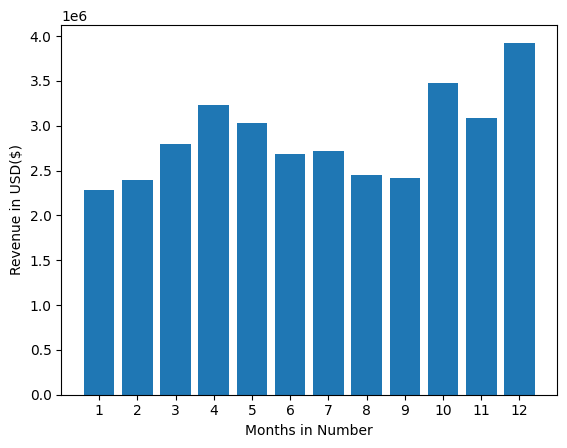

In [167]:
months=range(1,13)

plt.bar(months,all_month_revenue)
plt.xticks(months)
plt.ylabel('Revenue in USD($)')
plt.xlabel('Months in Number')


In [182]:
df['City'].unique()

array([' New York City', ' San Francisco', ' Atlanta', ' Portland',
       ' Dallas', ' Los Angeles', ' Boston', ' Austin', ' Seattle'],
      dtype=object)

In [183]:
df.drop(columns='City',inplace=True)

In [ ]:
# what US city has highest Number of sales


# Get the second item (index 1) after splitting
# 
# df['City'] = df['Purchase Address'].str.split(',').str[1] OR 

def get_city(address):
    return address.split(',')[1]

def get_state(address):
    return address.split(',')[2].split(' ')[1]

df['City'] = df['Purchase Address'].apply(lambda x: get_city(x)+" "+ get_state(x))

# City_c= lambda x.split(',')[1]: x in address

City_Revenue=df.groupby('City')['Net_Revenue'].sum()

City_Revenue


City
Atlanta GA          2795498.58
Austin TX           1819581.75
Boston MA           3661642.01
Dallas TX           2767975.40
Los Angeles CA      5452570.80
New York City NY    4664317.43
Portland ME          449758.27
Portland OR         1870732.34
San Francisco CA    8262203.91
Seattle WA          2747755.48
Name: Net_Revenue, dtype: float64

In [ ]:
df['City2'] = df['Purchase Address'].str.split(',').str[1]
df.groupby('City2')['Net_Revenue'].sum()

# Just to check if that made a difference in our earlier result

City2
Atlanta          2795498.58
Austin           1819581.75
Boston           3661642.01
Dallas           2767975.40
Los Angeles      5452570.80
New York City    4664317.43
Portland         2320490.61
San Francisco    8262203.91
Seattle          2747755.48
Name: Net_Revenue, dtype: float64

Text(0.5, 0, 'City Name')

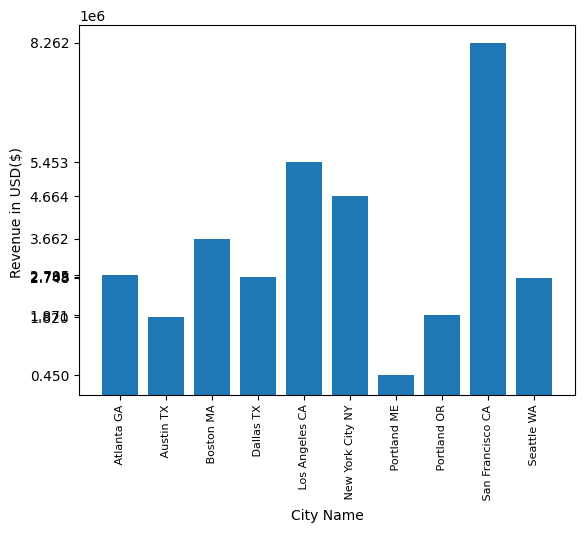

In [211]:
City=[cit for cit,df in df.groupby('City')]
plt.bar(City,City_Revenue)
plt.xticks(City,rotation='vertical',size=8)
plt.yticks(City_Revenue,)
plt.ylabel('Revenue in USD($) ')
plt.xlabel('City Name')


In [259]:
# What time we display ads to maximize lilelyhood of customer buying product

df['Hour']=df['Order Date'].dt.hour

Time_revenue=df.groupby('Hour')['Net_Revenue'].count()


In [254]:
Hours_count=df['Hour'].value_counts()

Text(0, 0.5, 'Count of orders')

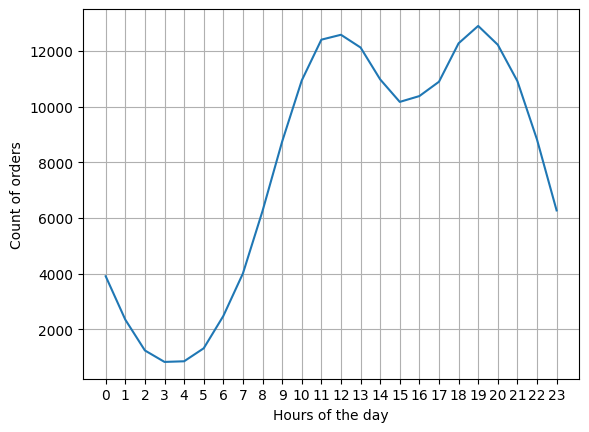

In [258]:
hours=[hour for hour,df1 in df.groupby('Hour')]
plt.plot(hours,Time_revenue)
plt.xticks(hours)
plt.grid()
plt.xlabel('Hours of the day')
plt.ylabel('Count of orders')


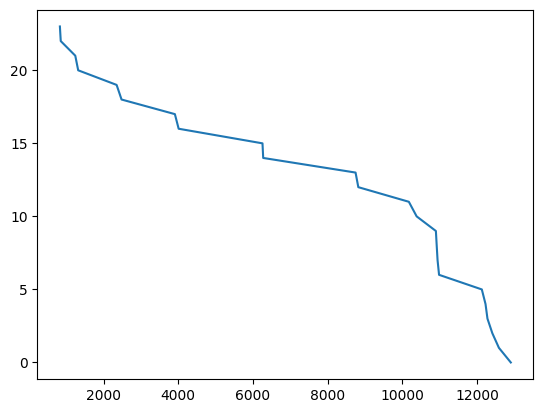

In [ ]:
plt.plot(Hours_count,hours) # why this is wrong or meaniless 

In [261]:
# what products are most often sold together

df['Product'].value_counts()

Product
USB-C Charging Cable          21903
Lightning Charging Cable      21658
AAA Batteries (4-pack)        20641
AA Batteries (4-pack)         20577
Wired Headphones              18882
Apple Airpods Headphones      15549
Bose SoundSport Headphones    13325
27in FHD Monitor               7507
iPhone                         6842
27in 4K Gaming Monitor         6230
34in Ultrawide Monitor         6181
Google Phone                   5525
Flatscreen TV                  4800
Macbook Pro Laptop             4724
ThinkPad Laptop                4128
20in Monitor                   4101
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

In [268]:
df_dupe=df[df['Order ID'].duplicated(keep=False)]

# Group by Order ID and join the product names
df_dupe['Grouped'] = df_dupe.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

# Drop the duplicate Order IDs now that we have the grouped string
df_dupe = df_dupe[['Order ID', 'Grouped']].drop_duplicates()
df_dupe

/var/folders/dq/0vzx57m16bqf591xn230qxbh0000gn/T/ipykernel_68279/1659639454.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dupe['Grouped'] = df_dupe.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))


,Order ID,Grouped
16,295681,"Google Phone,USB-C Charging Cable,Bose SoundSp..."
36,295698,"Vareebadd Phone,USB-C Charging Cable"
42,295703,"AA Batteries (4-pack),Bose SoundSport Headphones"
66,295726,"iPhone,Lightning Charging Cable"
76,295735,"iPhone,Apple Airpods Headphones,Wired Headphones"
...,...,...
186798,222863,"27in FHD Monitor,Bose SoundSport Headphones"
186804,222868,"iPhone,Apple Airpods Headphones"
186819,222882,"Apple Airpods Headphones,AA Batteries (4-pack)"
186822,222884,"Google Phone,USB-C Charging Cable"


In [269]:
from itertools import combinations
from collections import Counter

count = Counter()

for row in df_dupe['Grouped']:
    row_list = row.split(',')
    # This counts pairs (change the 2 to 3 for triplets)
    count.update(Counter(combinations(row_list, 2)))

# View the top 10 most common pairs
for key, value in count.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


In [276]:
# What product sold the most ? why do you think it sold the most?

df.groupby('Product')['Quantity Ordered'].sum()


Product
20in Monitor                   4129
27in 4K Gaming Monitor         6244
27in FHD Monitor               7550
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31017
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
Flatscreen TV                  4819
Google Phone                   5532
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23217
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
USB-C Charging Cable          23975
Vareebadd Phone                2068
Wired Headphones              20557
iPhone                         6849
Name: Quantity Ordered, dtype: int64

Text(0, 0.5, 'Quantity')

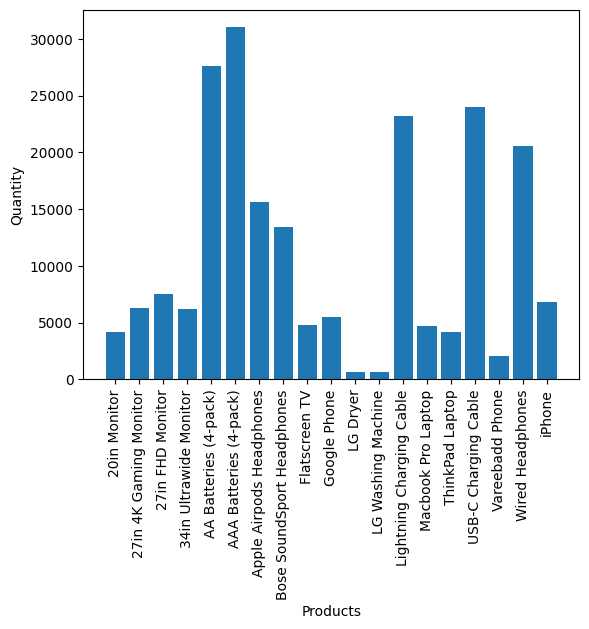

In [286]:
Quantity=df.groupby('Product')['Quantity Ordered'].sum()

product= [product for product,df1 in df.groupby('Product')]
plt.bar(product,Quantity)
plt.xticks(product,rotation='vertical')
plt.xlabel('Products')
plt.ylabel('Quantity')

Text(0.5, 0, 'Quarter')

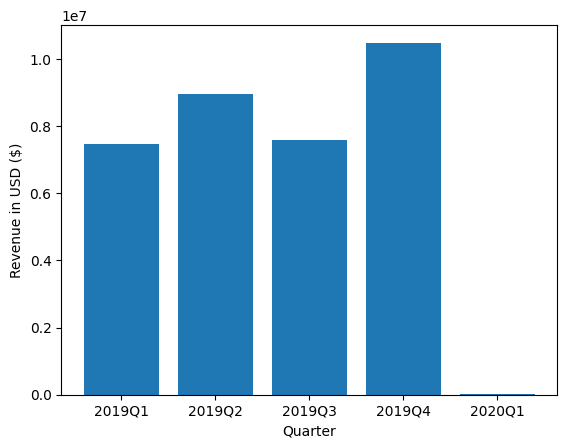

In [ ]:
# Most successful Quater of the year

Quater=[str(Quater) for Quater,df1 in df.groupby('Order_quater')]

Quaterly_revenue=df.groupby('Order_quater')['Net_Revenue'].sum()

plt.bar(Quater,Quaterly_revenue)
plt.ylabel('Revenue in USD ($)')
plt.xlabel('Quarter')